### Import Libaries

In [ ]:
###############################################################################
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
# ###############################################################################
import warnings
warnings.filterwarnings('ignore')
# ###############################################################################
print("Done")
# ###############################################################################

Done


### Load in data

In [ ]:
###############################################################################
thisDirName = str(globals()['_dh'][0]) + '/weatherForcastingCalculator/'
with open(thisDirName + 'Data/weatherDataJSONObject.json', 'r') as f:
    weatherDataDictObjectAll = json.load(f)
dfStations = pd.read_csv(thisDirName +"/Data/Weather Stations Info.csv")
###############################################################################
listOfStationKeys = list(weatherDataDictObjectAll.keys())
print(listOfStationKeys[:5])
print()
###############################################################################
print(dfStations.shape)
dfStations.head()
###############################################################################

['AK_Aleknagik_1_NNE', 'AK_Bethel_87_WNW', 'AK_Cordova_14_ESE', 'AK_Deadhorse_3_S', 'AK_Denali_27_N']

(132, 4)


,City,Longitude,Latitude,Elevation
0,AL_Brewton_3_NNE,-87.05,31.14,52.0
1,AL_Clanton_2_NE,-86.61,32.85,174.0
2,AL_Courtland_2_WSW,-87.35,34.66,175.0
3,AL_Cullman_3_ENE,-86.80,34.20,253.0
4,AL_Fairhope_3_NE,-87.88,30.55,40.0


### Plot the lat and long of data

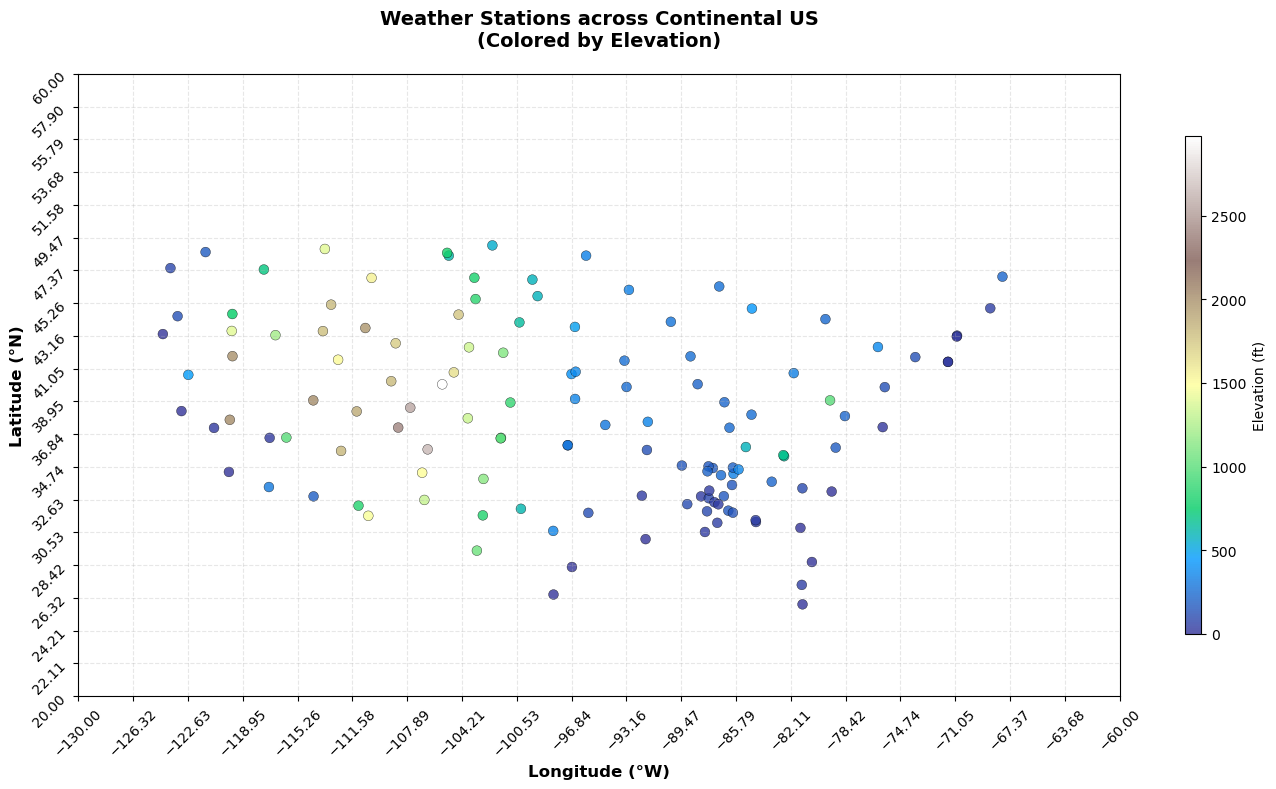

In [ ]:
###############################################################################
# Create the improved plot
plt.figure(figsize=(14, 8))
cm = plt.cm.get_cmap('terrain')
sc = plt.scatter(
    np.float64(dfStations['Longitude'].values.flatten()), 
    np.float64(dfStations['Latitude'].values.flatten()), 
    c=np.float64(dfStations['Elevation'].values.flatten()), 
    cmap=cm,
    s=50,
    alpha=0.8,
    edgecolors='black',
    linewidth=0.3  # Thin outline
)
###############################################################################
# Improved colorbar
cbar = plt.colorbar(sc, label='Elevation (ft)', shrink=0.8, aspect=30)
cbar.ax.tick_params(labelsize=10)
###############################################################################
# Better tick spacing - fewer ticks for cleaner look
xticks = np.round(np.linspace(-130, -60, 20), 3).tolist()
yticks = np.round(np.linspace(20, 60, 20), 3).tolist()
plt.xlim([min(xticks), max(xticks)]) # Longitude
plt.ylim([min(yticks), max(yticks)]) # Latitude
plt.xticks(xticks, rotation=45)
plt.yticks(yticks, rotation=45)
###############################################################################
# Improved labels and title
plt.xlabel('Longitude (°W)', fontsize=12, fontweight='bold')
plt.ylabel('Latitude (°N)', fontsize=12, fontweight='bold')
plt.title('Weather Stations across Continental US\n(Colored by Elevation)', fontsize=14, fontweight='bold', pad=20)
###############################################################################
# Improved grid
plt.grid(True, alpha=0.3, linestyle='--')
###############################################################################
# Tight layout for better spacing
plt.tight_layout()
plt.show()
###############################################################################

### Data Cleaning Functions

In [ ]:
###############################################################################
# Data Cleaning Functions
###############################################################################
def replaceInvalidDataWithNaN(stationDict={}, keysList=[], i=0):
    try:
        valRawDataFloat = np.array(stationDict[keysList[i]]).flatten().astype(float)
        valCleanDataPartI = np.where((valRawDataFloat == -99.0) | (valRawDataFloat == -9999.0), np.nan, valRawDataFloat)
        stationDict[keysList[i]] = valCleanDataPartI
    except: # i.e., cannot convert valRawDataFloat to float
        stationDict[keysList[i]] = np.array(stationDict[keysList[i]]).flatten()
    return stationDict
###############################################################################
# Initial Clean up of each data
stationsKeysList = list(weatherDataDictObjectAll.keys())
for j in range(0, len(stationsKeysList)):
    stationDict = weatherDataDictObjectAll[stationsKeysList[j]]
    keysList = list(stationDict.keys())
    for i in range(0, len(keysList)):
        # adding data cleaning functions here
        # stationDict = replaceInvalidDataWithNaN(stationDict=stationDict, keysList=keysList, i=i)
        c = 1
    weatherDataDictObjectAll[stationsKeysList[j]] = stationDict
###############################################################################
# weatherDataDictObjectAll[stationsKeysList[0]]
###############################################################################
print("Done")
###############################################################################

Done
